In [1]:
import os

In [2]:
os.environ['KAGGLE_USERNAME']='jayasankarkalahasti'
os.environ['KAGGLE_KEY']='3c86e162caee2b057fdb70f0c0ae3c3e'

In [3]:
!pip install kaggle

In [4]:
!kaggle datasets download -d 'toriqulstu/worlds-real-estate-data147k'

Dataset URL: https://www.kaggle.com/datasets/toriqulstu/worlds-real-estate-data147k
License(s): CC0-1.0
100% 5.88M/5.88M [00:00<00:00, 87.5MB/s]



In [5]:
!unzip /content/worlds-real-estate-data147k.zip

Archive:  /content/worlds-real-estate-data147k.zip
  inflating: world_real_estate_data(147k).csv  


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error
import warnings
warnings.filterwarnings("ignore")

In [8]:
df=pd.read_csv('/content/world_real_estate_data(147k).csv')

In [9]:
df

,title,country,location,building_construction_year,building_total_floors,apartment_floor,apartment_rooms,apartment_bedrooms,apartment_bathrooms,apartment_total_area,apartment_living_area,price_in_USD,image,url
0,2 room apartment 120 m² in Mediterranean Regio...,Turkey,"Mediterranean Region, Turkey",NaN,5.0,1.0,3.0,2.0,2.0,120 m²,110 m²,315209.0,https://realting.com/uploads/bigSlider/ab3/888...,https://realting.com/property-for-sale/turkey/...
1,"4 room villa 500 m² in Kalkan, Turkey",Turkey,"Kalkan, Mediterranean Region, Kas, Turkey",2021.0,2.0,NaN,NaN,NaN,NaN,500 m²,480 m²,1108667.0,https://realting.com/uploads/bigSlider/87b/679...,https://realting.com/property-for-sale/turkey/...
2,"1 room apartment 65 m² in Antalya, Turkey",Turkey,"Mediterranean Region, Antalya, Turkey",NaN,5.0,2.0,2.0,1.0,1.0,65 m²,60 m²,173211.0,https://realting.com/uploads/bigSlider/030/a11...,https://realting.com/property-for-sale/turkey/...
3,"1 room apartment in Pattaya, Thailand",Thailand,"Chon Buri Province, Pattaya, Thailand",2020.0,15.0,5.0,2.0,1.0,1.0,NaN,40 m²,99900.0,https://realting.com/uploads/bigSlider/e9a/e06...,https://realting.com/property-for-sale/thailan...
4,"2 room apartment in Pattaya, Thailand",Thailand,"Chon Buri Province, Pattaya, Thailand",2026.0,8.0,3.0,3.0,2.0,1.0,NaN,36 m²,67000.0,https://realting.com/uploads/bigSlider/453/aa2...,https://realting.com/property-for-sale/thailan...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
147531,"5 room apartment 310 m² in Gazipasa, Turkey",Turkey,"Mediterranean Region, Gazipasa, Turkey",NaN,NaN,NaN,NaN,5.0,NaN,310 m²,NaN,597810.0,https://realting.com/uploads/bigSlider/e4a/67f...,https://realting.com/property-for-sale/turkey/...
147532,"4 room apartment 192 m² in Marmara Region, Turkey",Turkey,"Marmara Region, Turkey",2023.0,5.0,NaN,5.0,4.0,2.0,192 m²,151 m²,637195.0,https://realting.com/uploads/bigSlider/93e/5c6...,https://realting.com/property-for-sale/turkey/...
147533,"2 room apartment in Marmara Region, Turkey",Turkey,"Marmara Region, Turkey",NaN,NaN,NaN,3.0,2.0,2.0,NaN,84 m²,477146.0,https://realting.com/uploads/bigSlider/4ae/9d8...,https://realting.com/property-for-sale/turkey/...
147534,"Apartment in Akarca, Turkey",Turkey,"Akarca, Central Anatolia Region, Turkey",2023.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,819163.0,https://realting.com/uploads/bigSlider/164/7e6...,https://realting.com/property-for-sale/turkey/...


In [10]:
print("Shape of Dataset:", df.shape)
print("\nColumn Names:")
print(df.columns)
print("\nDataset Information:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())

Shape of Dataset: (147536, 14)

Column Names:
Index(['title', 'country', 'location', 'building_construction_year',
       'building_total_floors', 'apartment_floor', 'apartment_rooms',
       'apartment_bedrooms', 'apartment_bathrooms', 'apartment_total_area',
       'apartment_living_area', 'price_in_USD', 'image', 'url'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147536 entries, 0 to 147535
Data columns (total 14 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   title                       147536 non-null  object 
 1   country                     147406 non-null  object 
 2   location                    147405 non-null  object 
 3   building_construction_year  64719 non-null   float64
 4   building_total_floors       68224 non-null   float64
 5   apartment_floor             54592 non-null   float64
 6   apartment_rooms             74178 non-null   float

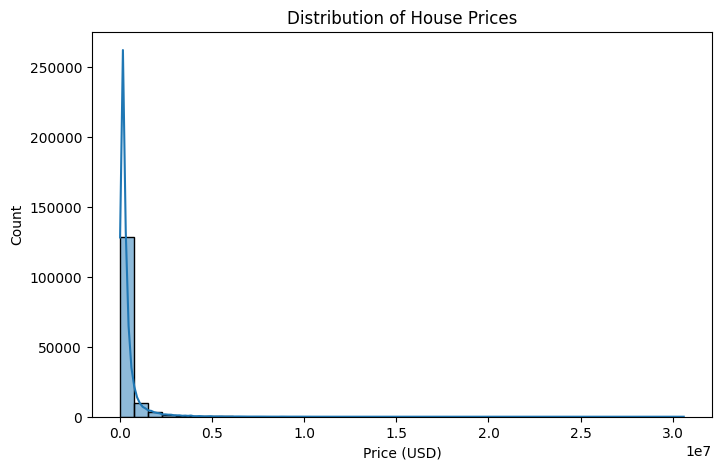

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df['price_in_USD'], bins=40, kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("Price (USD)")
plt.ylabel("Count")
plt.show()

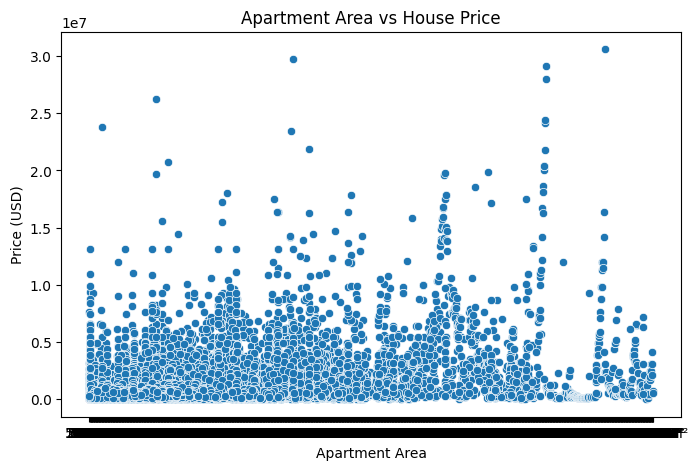

In [12]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='apartment_total_area',y='price_in_USD',data=df)
plt.title("Apartment Area vs House Price")
plt.xlabel("Apartment Area")
plt.ylabel("Price (USD)")
plt.show()

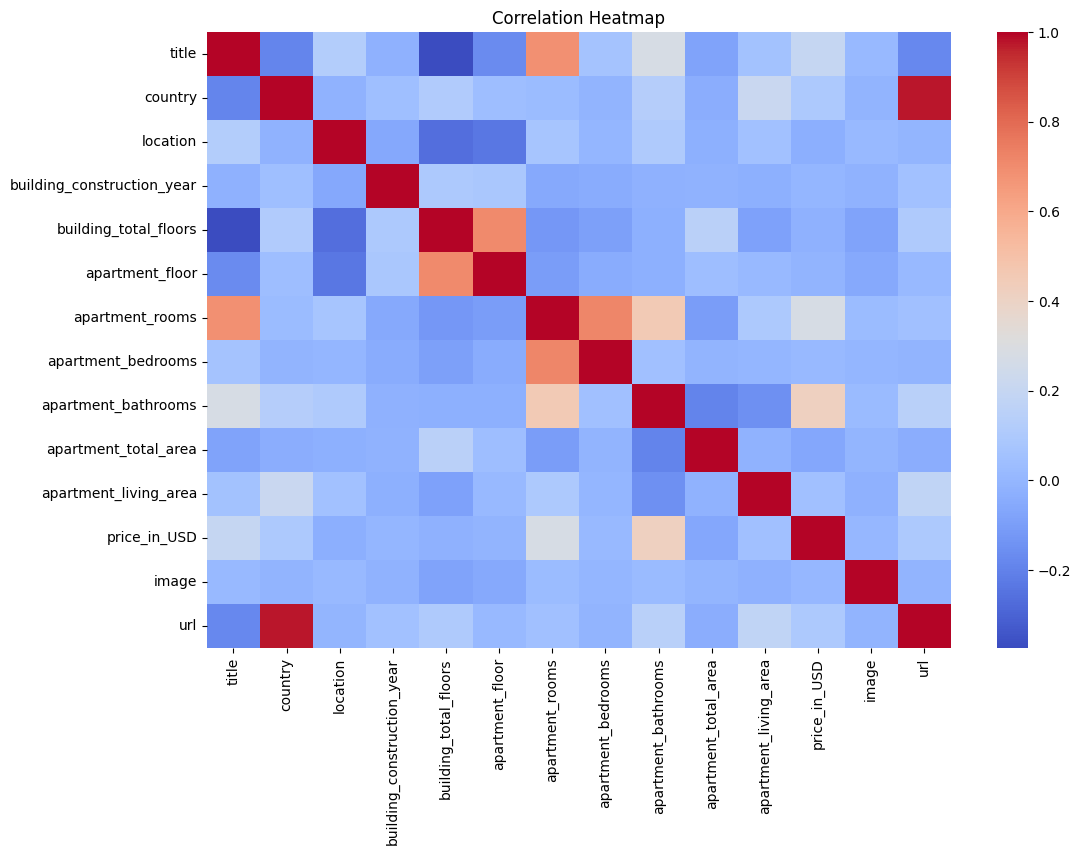

In [13]:
temp = df.copy()
le = LabelEncoder()
for col in temp.select_dtypes(include='object').columns:
    temp[col] = le.fit_transform(temp[col].astype(str))
plt.figure(figsize=(12,8))
sns.heatmap(temp.corr(),cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [14]:
df.drop_duplicates(inplace=True)

In [15]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

In [16]:
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [17]:
drop_cols = []
for col in ['url','image']:
    if col in df.columns:
        drop_cols.append(col)
df.drop(columns=drop_cols, inplace=True)

In [19]:
df['apartment_total_area'] = pd.to_numeric(df['apartment_total_area'], errors='coerce')
df['apartment_total_area'].fillna(df['apartment_total_area'].median(), inplace=True)
df['price_per_sqm'] = df['price_in_USD'] / df['apartment_total_area']
df['house_age'] = 2026 - df['building_construction_year']
df['total_rooms'] = (df['apartment_bedrooms'] +df['apartment_bathrooms'])

In [21]:
median_price = df['price_in_USD'].median()
df['luxury_house'] = np.where(
    df['price_in_USD'] > median_price,
    1,
    0
)

In [22]:
df['area_category'] = pd.cut(
    df['apartment_total_area'],
    bins=[0,50,100,200,10000],
    labels=['Small','Medium','Large','Luxury']
)

In [23]:
df

,title,country,location,building_construction_year,building_total_floors,apartment_floor,apartment_rooms,apartment_bedrooms,apartment_bathrooms,apartment_total_area,apartment_living_area,price_in_USD,price_per_sqm,house_age,total_rooms,luxury_house,area_category
0,2 room apartment 120 m² in Mediterranean Regio...,Turkey,"Mediterranean Region, Turkey",2021.0,5.0,1.0,3.0,2.0,2.0,NaN,110 m²,315209.0,NaN,5.0,4.0,1,NaN
1,"4 room villa 500 m² in Kalkan, Turkey",Turkey,"Kalkan, Mediterranean Region, Kas, Turkey",2021.0,2.0,4.0,2.0,2.0,1.0,NaN,480 m²,1108667.0,NaN,5.0,3.0,1,NaN
2,"1 room apartment 65 m² in Antalya, Turkey",Turkey,"Mediterranean Region, Antalya, Turkey",2021.0,5.0,2.0,2.0,1.0,1.0,NaN,60 m²,173211.0,NaN,5.0,2.0,0,NaN
3,"1 room apartment in Pattaya, Thailand",Thailand,"Chon Buri Province, Pattaya, Thailand",2020.0,15.0,5.0,2.0,1.0,1.0,NaN,40 m²,99900.0,NaN,6.0,2.0,0,NaN
4,"2 room apartment in Pattaya, Thailand",Thailand,"Chon Buri Province, Pattaya, Thailand",2026.0,8.0,3.0,3.0,2.0,1.0,NaN,36 m²,67000.0,NaN,0.0,3.0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
147531,"5 room apartment 310 m² in Gazipasa, Turkey",Turkey,"Mediterranean Region, Gazipasa, Turkey",2021.0,5.0,4.0,2.0,5.0,1.0,NaN,30 m²,597810.0,NaN,5.0,6.0,1,NaN
147532,"4 room apartment 192 m² in Marmara Region, Turkey",Turkey,"Marmara Region, Turkey",2023.0,5.0,4.0,5.0,4.0,2.0,NaN,151 m²,637195.0,NaN,3.0,6.0,1,NaN
147533,"2 room apartment in Marmara Region, Turkey",Turkey,"Marmara Region, Turkey",2021.0,5.0,4.0,3.0,2.0,2.0,NaN,84 m²,477146.0,NaN,5.0,4.0,1,NaN
147534,"Apartment in Akarca, Turkey",Turkey,"Akarca, Central Anatolia Region, Turkey",2023.0,5.0,4.0,2.0,2.0,1.0,NaN,30 m²,819163.0,NaN,3.0,3.0,1,NaN


In [24]:
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])
df['area_category'] = LabelEncoder().fit_transform(df['area_category'])

In [25]:
X = df.drop("price_in_USD", axis=1)
y = df["price_in_USD"]

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20, random_state=42)

In [27]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [28]:
!pip install xgboost

In [29]:
from xgboost import XGBRegressor
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [30]:
prediction = model.predict(X_test)
print("R² Score :", r2_score(y_test, prediction))
print("Mean Absolute Error :", mean_absolute_error(y_test, prediction))

R² Score : 0.555656437872709
Mean Absolute Error : 179278.6946122282


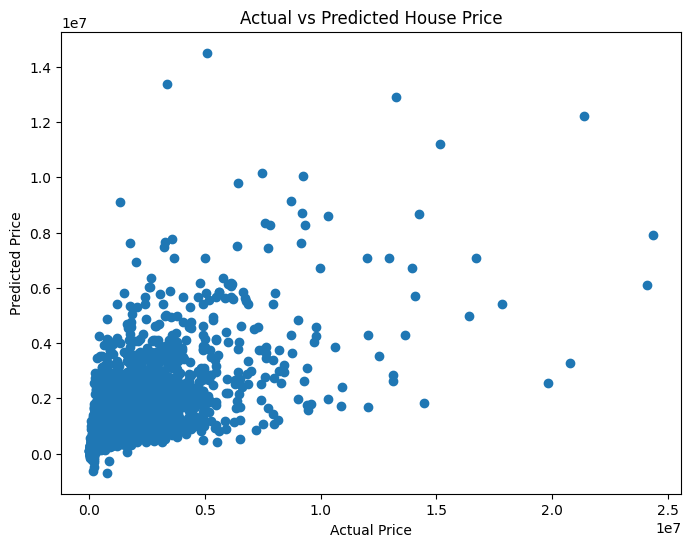

In [31]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, prediction)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Price")
plt.show()

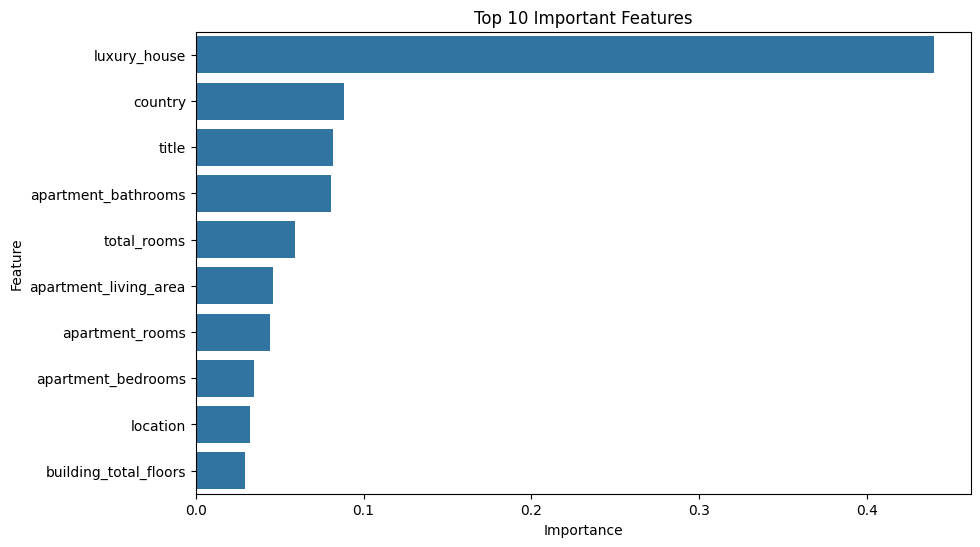

In [32]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})
importance = importance.sort_values(
    by="Importance",
    ascending=False
)
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)
plt.title("Top 10 Important Features")
plt.show()

In [33]:
import joblib
joblib.dump(model, "house_price_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [34]:
print(X.columns.tolist())

['title', 'country', 'location', 'building_construction_year', 'building_total_floors', 'apartment_floor', 'apartment_rooms', 'apartment_bedrooms', 'apartment_bathrooms', 'apartment_total_area', 'apartment_living_area', 'price_per_sqm', 'house_age', 'total_rooms', 'luxury_house', 'area_category']


In [36]:
title = int(input("Enter Title (Encoded): "))
country = int(input("Enter Country (Encoded): "))
location = int(input("Enter Location (Encoded): "))
construction_year = int(input("Enter Construction Year: "))
building_total_floors = int(input("Enter Total Floors: "))
apartment_floor = int(input("Enter Apartment Floor: "))
apartment_rooms = int(input("Enter Number of Rooms: "))
apartment_bedrooms = int(input("Enter Number of Bedrooms: "))
apartment_bathrooms = int(input("Enter Number of Bathrooms: "))
apartment_total_area = float(input("Enter Total Area (sq.m): "))
apartment_living_area = float(input("Enter Living Area (sq.m): "))



house_age = 2026 - construction_year

total_rooms = apartment_bedrooms + apartment_bathrooms
price_per_sqm = 0
luxury_house = 0
if apartment_total_area <= 50:
    area_category = 0
elif apartment_total_area <= 100:
    area_category = 1
elif apartment_total_area <= 200:
    area_category = 2
else:
    area_category = 3

sample = [[
    title,
    country,
    location,
    construction_year,
    building_total_floors,
    apartment_floor,
    apartment_rooms,
    apartment_bedrooms,
    apartment_bathrooms,
    apartment_total_area,
    apartment_living_area,
    price_per_sqm,
    house_age,
    total_rooms,
    luxury_house,
    area_category
]]


sample = scaler.transform(sample)

prediction = model.predict(sample)

print("\n===============================")
print(" HOUSE PRICE PREDICTION RESULT ")
print("===============================")
print(f"Estimated House Price (USD): ${prediction[0]:,.2f}")


Enter Title (Encoded): 10
Enter Country (Encoded): 5
Enter Location (Encoded): 120
Enter Construction Year: 2018
Enter Total Floors: 12
Enter Apartment Floor: 5
Enter Number of Rooms: 4
Enter Number of Bedrooms: 3
Enter Number of Bathrooms: 2
Enter Total Area (sq.m): 120
Enter Living Area (sq.m): 95

 HOUSE PRICE PREDICTION RESULT 
Estimated House Price (USD): $117,292.64
